# Questão 3

In [1]:
from examples.seismic.source import RickerSource, TimeAxis
from examples.seismic import AcquisitionGeometry
try:
    from examples.seismic.stiffness.model import ElasticModel
except:
    from examples.seismic.stiffness.model import ISOSeismicModel as ElasticModel
from examples.seismic.stiffness.utils import C_Matrix
from devito import *
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

configuration['log-level'] = 'WARNING'

%matplotlib inline

mpi4py is not available. You must install it


# Preparação do ambiente

## Parâmetros dos operadores de diferenças finitas

In [2]:
space_order=8
time_order=2

## Definição do modelo

### Dimensões do modelo

A frequência máxima escolhida foi $30$ $\mathrm{Hz}$, a ordem das derivadas espaciais é $8$ ($F=4$) e a velocidade mínima de propagação é $1000$ $\mathrm{m/s}$. Logo, o espaçamento máximo obedecerá

$$
\begin{aligned}
    \max(\Delta x, \Delta y, \Delta z) &\le \frac{\min(v_P, v_S)}{F f_{\max}}\\
        &= \frac{1000\ \mathrm{m/s}}{4 \times 30\ \mathrm{Hz}}\\
        &= 8 + \frac{1}{3}
\end{aligned}
$$

<!-- , a frequência de pico de uma fonte Ricker será aproximadamente $15$ $\mathrm{Hz}$. -->

Com base nisto, foi escolhido um espaçamento de $\Delta x = \Delta y = \Delta z = 8\ \mathrm{m}$. Visto que o modelo possui dimensões $w \times h \times d = 2000\ \mathrm{m} \times 2000\ \mathrm{m} \times 2000\ \mathrm{m}$, a malha terá
$$
n_x = \frac{w}{\Delta x} + 1 = \frac{2000\ \mathrm{m}}{8\ \mathrm{m}} + 1 = 251
$$
pontos ao longo do eixo x,
$$
n_y = \frac{h}{\Delta y} + 1 = \frac{2000\ \mathrm{m}}{8\ \mathrm{m}} + 1 = 251
$$
pontos ao longo do eixo y, e
$$
n_z = \frac{d}{\Delta z} + 1 = \frac{2000\ \mathrm{m}}{8\ \mathrm{m}} + 1 = 251
$$
pontos ao longo do eixo z.

In [3]:
# shape = (251, 251, 251)
# shape = (101, 51, 101)
shape = (71, 71, 71)
spacing = (8, 8, 8)
origin = (0., 0., 0)
nbl=1

### Parâmetros físicos

O modelo possui uma única camada cuja velocidade de propagação das ondas P e S são respectivamente $v_P = 2$ $\mathrm{km/s}$ e $v_S = 1$ $\mathrm{km/s}$, e cuja densidade $\rho$ é $1.8$ $\mathrm{g/cm^3}$.

In [4]:
vp = 2.0 * np.ones(shape, dtype=np.float32) # Velocidade da onda P em km/s
vs = np.ones(shape, dtype=np.float32) # Velocidade da onda S em km/s
rho = 1.8 * np.ones(shape, dtype=np.float32) # Densidade em g/cm^3

In [5]:
model = ElasticModel(vp=vp, vs=vs, b=1/rho, origin=origin, shape=shape, spacing=spacing,
              space_order=space_order, nbl=nbl, bcs="damp")

## Parâmetros da aquisição

### Tempo de aquisição

O período de aquisição inicia em $t_0 = 0$ $\mathrm{ms}$ e termina em $t_n = 200$ $\mathrm{ms}$. 

O comprimento do passo temporal, $\Delta t$, foi escolhido a partir da condição de estabilidade:
$$
\begin{aligned}
    \Delta t &\le \frac{1}{\max(v_P, v_S)\sqrt{\dfrac{1}{\Delta x^2} + \dfrac{1}{\Delta y^2} + \dfrac{1}{\Delta z^2}}}\\
        &= \frac{1}{2000\ \mathrm{m/s} \sqrt{\dfrac{1}{(8\ \mathrm{m})^2} + \dfrac{1}{(8\ \mathrm{m})^2} + \dfrac{1}{(8\ \mathrm{m})^2}}}\\
        &\approx 2.3094\ \mathrm{ms}
\end{aligned}
$$
Com base nisto, o comprimento do passo temporal escolhido foi $\Delta t = 1.5\ \mathrm{ms}$.

In [ ]:
t0 = 0.  # ms
tn = 200. # ms
dt = 1.5

time_range = TimeAxis(start=t0, stop=tn, step=dt)

### Geometria

A assinatura da fonte será a fonte de Ricker, que possui uma frequência de pico $f_{\mathrm{peak}} \approx \dfrac{1}{3} f_{\mathrm{max}} = \dfrac{1}{3}0.030\ \mathrm{kHz} = 0.010\ \mathrm{kHz}$.

In [7]:
# Frequência de pico da fonte
f0 = 0.010

In [8]:
zero_coords = np.array([[0,0,0]], dtype=model.dtype) # Para zerar as coordenadas da fonte e dos receptores da geometria.
geometry = AcquisitionGeometry(model, zero_coords, zero_coords, t0, tn)
geometry.resample(dt)

time_range = geometry.time_axis

### Geometria

Será utilizada uma fonte Ricker, que é parametrizada com uma frequência de pico $f_0 \approx \dfrac{f_{\max}}{3} = 10\ \mathrm{Hz}$.

In [9]:
src = RickerSource(name='src', grid=model.grid, f0=f0,
                   npoint=1, time_range=time_range)

src.coordinates.data[0, :] = np.array(model.domain_size) * .5

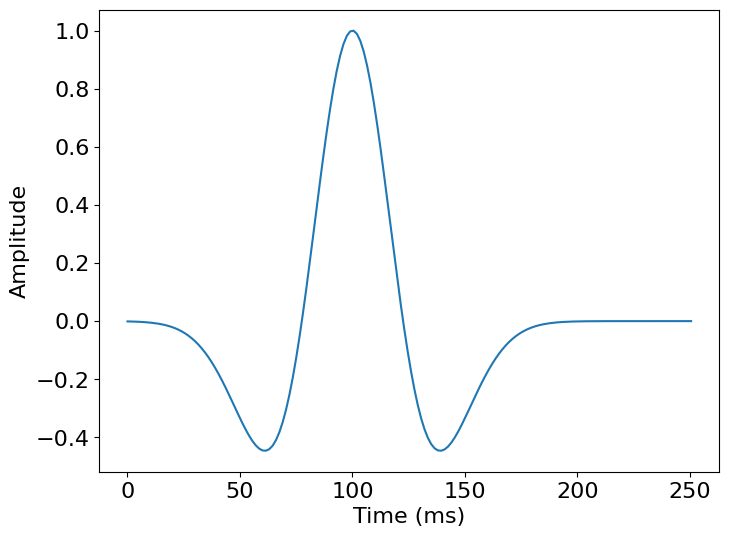

In [10]:
src.show() # Assinatura da fonte

# Resolução da alternativa a)

### Definição da equação da onda elástica de 2ª ordem

Aqui é definida no *Devito* a equação

$$
\rho\frac{\partial^2 \mathbf{u}}{\partial t^2} - DCD^T\mathbf{u} = \mathbf{F}
$$

em que:

- $\mathbf{u}$ é o campo de deslocamento de partícula;
- $C$ é a matriz de rigidez;
- $D$ é a matriz de derivadas espaciais;
- $\mathbf{F}$ é o termo fonte;

In [11]:
def make_DCDT_transform(model: ElasticModel):
    """
    Returns the transform $DCD^T$ to be applied over a 3-dimensional vector field.

    Parameters
    ----------
    
    model : ElasticModel

        The model containing the physical parameters of the medium.

    Returns
    -------

    The transform $DCD^T$.
    """
    def DCDT(u: VectorFunction):
        gradu_x = grad(u[0], .5)
        gradu_y = grad(u[1], .5)
        gradu_z = grad(u[2], .5)

        grad_pvp_uxdx = grad(model.rho * model.vp**2 * gradu_x[0], -.5)
        grad_pvp_uxdy = grad(model.rho * model.vp**2 * gradu_x[1], -.5)
        grad_pvp_uxdz = grad(model.rho * model.vp**2 * gradu_x[2], -.5)
        
        grad_pvp_uydx = grad(model.rho * model.vp**2 * gradu_y[0], -.5)
        grad_pvp_uydy = grad(model.rho * model.vp**2 * gradu_y[1], -.5)
        grad_pvp_uydz = grad(model.rho * model.vp**2 * gradu_y[2], -.5)
        
        grad_pvp_uzdx = grad(model.rho * model.vp**2 * gradu_z[0], -.5)
        grad_pvp_uzdy = grad(model.rho * model.vp**2 * gradu_z[1], -.5)
        grad_pvp_uzdz = grad(model.rho * model.vp**2 * gradu_z[2], -.5)
        
        grad_pvs_uxdx = grad(model.rho * model.vs**2 * gradu_x[0], -.5)
        grad_pvs_uxdy = grad(model.rho * model.vs**2 * gradu_x[1], -.5)
        grad_pvs_uxdz = grad(model.rho * model.vs**2 * gradu_x[2], -.5)
        
        grad_pvs_uydx = grad(model.rho * model.vs**2 * gradu_y[0], -.5)
        grad_pvs_uydy = grad(model.rho * model.vs**2 * gradu_y[1], -.5)
        grad_pvs_uydz = grad(model.rho * model.vs**2 * gradu_y[2], -.5)
        
        grad_pvs_uzdx = grad(model.rho * model.vs**2 * gradu_z[0], -.5)
        grad_pvs_uzdy = grad(model.rho * model.vs**2 * gradu_z[1], -.5)
        grad_pvs_uzdz = grad(model.rho * model.vs**2 * gradu_z[2], -.5)

        dvpd_ux = [
            [ grad_pvp_uxdx[0], grad_pvp_uxdx[1], grad_pvp_uxdx[2]],
            [ grad_pvp_uxdy[0], grad_pvp_uxdy[1], grad_pvp_uxdy[2]],
            [ grad_pvp_uxdz[0], grad_pvp_uxdz[1], grad_pvp_uxdz[2]],
        ]
        dvpd_uy = [
            [ grad_pvp_uydx[0], grad_pvp_uydx[1], grad_pvp_uydx[2]],
            [ grad_pvp_uydy[0], grad_pvp_uydy[1], grad_pvp_uydy[2]],
            [ grad_pvp_uydz[0], grad_pvp_uydz[1], grad_pvp_uydz[2]],
        ]
        dvpd_uz = [
            [ grad_pvp_uzdx[0], grad_pvp_uzdx[1], grad_pvp_uzdx[2]],
            [ grad_pvp_uzdy[0], grad_pvp_uzdy[1], grad_pvp_uzdy[2]],
            [ grad_pvp_uzdz[0], grad_pvp_uzdz[1], grad_pvp_uzdz[2]],
        ]
        
        dvsd_ux = [
            [ grad_pvs_uxdx[0], grad_pvs_uxdx[1], grad_pvs_uxdx[2]],
            [ grad_pvs_uxdy[0], grad_pvs_uxdy[1], grad_pvs_uxdy[2]],
            [ grad_pvs_uxdz[0], grad_pvs_uxdz[1], grad_pvs_uxdz[2]],
        ]
        dvsd_uy = [
            [ grad_pvs_uydx[0], grad_pvs_uydx[1], grad_pvs_uydx[2]],
            [ grad_pvs_uydy[0], grad_pvs_uydy[1], grad_pvs_uydy[2]],
            [ grad_pvs_uydz[0], grad_pvs_uydz[1], grad_pvs_uydz[2]],
        ]
        dvsd_uz = [
            [ grad_pvs_uzdx[0], grad_pvs_uzdx[1], grad_pvs_uzdx[2]],
            [ grad_pvs_uzdy[0], grad_pvs_uzdy[1], grad_pvs_uzdy[2]],
            [ grad_pvs_uzdz[0], grad_pvs_uzdz[1], grad_pvs_uzdz[2]],
        ]

        components = [
            dvpd_ux[0][0] + dvsd_ux[1][1] + dvsd_ux[2][2] + dvsd_uy[0][1] + dvsd_uz[0][2],
            dvsd_ux[1][0] + dvpd_uy[1][1] + dvsd_uy[2][2] + dvsd_uy[0][0] + dvsd_uz[2][1],
            dvsd_ux[1][0] + dvsd_uy[2][1] + dvpd_uz[2][2] + dvsd_uz[1][1] + dvsd_uz[0][0]
        ]

        DCDTu = VectorTimeFunction(name='DCDTu', grid=u.grid, time_order=u.time_order, space_order=u.space_order, 
                                components=components)

        return DCDTu

    return DCDT

In [12]:
DCDT = make_DCDT_transform(model)

In [13]:
u = VectorTimeFunction(name='u', grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt, 
                       staggered=[NODE, NODE, NODE]
                    )

In [14]:
# Equações da onda elástica de 2ª ordem

EDP = model.rho * u.dt2 - DCDT(u)

In [15]:
# Expressão para o campo de ondas futuro, u(x, t + dt)

stencil = Eq(u.forward, solve(EDP, u.forward))
stencil

Eq(Vector(u_x(time + dt, x, y, z), u_y(time + dt, x, y, z), u_z(time + dt, x, y, z)), Vector(dt**2*(-rho*(-2.0*u_x(time, x, y, z)/dt**2 + u_x(time - dt, x, y, z)/dt**2) + Derivative(rho*vp(x, y, z)**2*Derivative(u_x(time, x, y, z), x), x) + Derivative(rho*vs(x, y, z)**2*Derivative(u_x(time, x, y, z), y), y) + Derivative(rho*vs(x, y, z)**2*Derivative(u_x(time, x, y, z), z), z) + Derivative(rho*vs(x, y, z)**2*Derivative(u_y(time, x, y, z), x), y) + Derivative(rho*vs(x, y, z)**2*Derivative(u_z(time, x, y, z), x), z))/rho, dt**2*(-rho*(-2.0*u_y(time, x, y, z)/dt**2 + u_y(time - dt, x, y, z)/dt**2) + Derivative(rho*vs(x, y, z)**2*Derivative(u_x(time, x, y, z), y), x) + Derivative(rho*vs(x, y, z)**2*Derivative(u_y(time, x, y, z), x), x) + Derivative(rho*vp(x, y, z)**2*Derivative(u_y(time, x, y, z), y), y) + Derivative(rho*vs(x, y, z)**2*Derivative(u_y(time, x, y, z), z), z) + Derivative(rho*vs(x, y, z)**2*Derivative(u_z(time, x, y, z), z), y))/rho, dt**2*(-rho*(-2.0*u_z(time, x, y, z)/dt**2 

Com base na expressão acima para o campo $\mathbf{u}(\mathbf{x}, t + \Delta t)$, observa-se que o termo fonte possui um coeficiente igual a $\frac{1}{\rho}\Delta t^2$. Logo, a fonte $S$ deve ser injetada no campo de ondas futuro como $\frac{1}{\rho}\Delta t^2 S(\mathbf{x}, t)$.

In [16]:
# Símbolo do espaçamento temporal
s = model.grid.stepping_dim.spacing

# Expressão do termo fonte a ser injetada no stencil criado acima
src_term_x = src.inject(u[0].forward, expr = 1/model.rho * s**2 * src)
src_term_y = src.inject(u[1].forward, expr = 1/model.rho * s**2 * src)
src_term_z = src.inject(u[2].forward, expr = 1/model.rho * s**2 * src)


src_term = src_term_x + src_term_y + src_term_z
# src_term = src_term_x + src_term_z

### Criação do operador de diferenças finitas

In [17]:
# Criação do operador do Devito
op = Operator([stencil] + src_term, subs=model.spacing_map)

In [18]:
# Execução
op(dt=dt)

PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=0.8668970000000001, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section1', rank=None),
                     PerfEntry(time=0.00017999999999999966, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

### Plotagem do campo de ondas

In [19]:
def plot_wavefield_slice(u, geometry, src_pos, model, title=None, t0=0, tn=-1, rec_pos=None, y=-1):
    """
    Exibe o campo de onda em 4 instantes distribuídos em um período determinado por `t0` e `tn`
    """
    shape_pad = np.array(model.shape)
    origin_pad = origin
    extent_pad = tuple([s*(n-1) for s, n in zip(spacing, shape_pad)])

    # Note: flip direction of second dimension to make the plot positive downwards
    plt_extent = [origin_pad[0], origin_pad[0] + extent_pad[0],
                origin_pad[2] + extent_pad[2], origin_pad[2]]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True)
    fig.suptitle(title, size=20, y=1.05)
    isfirst = True
    last_ax = None
    last_plot = None

    t0 = t0 - geometry.t0
    tn = tn - geometry.t0

    snapshots = None
    if tn < 0:
        idx_min = max(int(np.round(t0/dt)), 0)
        snapshots = np.linspace(idx_min, geometry.nt - 1, num=4, dtype=np.int32)
    else:
        idx_min = max(int(np.round(t0/dt)), 0)
        idx_max = min(int(np.round(tn/dt)), geometry.nt - 1)
        snapshots = np.linspace(idx_min, idx_max, num=4, dtype=np.int32)


    udata = u.data
    amax = np.max(np.abs(udata[geometry.nt-1, :, :]))
    y_idx = y
    if y_idx < 0 or y_idx >= model.shape[1]:
        y_idx = model.shape[1]//2

    for count, ax in enumerate(axes.ravel()):
        snapshot = snapshots[count]
        last_plot = ax.imshow(udata[snapshot, model.nbl:-model.nbl, y_idx, model.nbl:-model.nbl].T,
                              cmap="seismic", 
                            vmin=-amax,
                  vmax=+amax, extent=plt_extent)
        ax.plot(src_pos[0], src_pos[2], 'red', linestyle='None', marker='*',
                markersize=8, label="Source")
        
        if type(rec_pos) != type(None):
            ax.plot(rec_pos[0], rec_pos[2], 'green', linestyle='None', marker='v',
                    markersize=8, label="Receiver")
            
        ax.grid()
        ax.tick_params('both', length=4, width=0.5, which='major', labelsize=11)

        ax.set_title("t=%.2fms" % (snapshot*dt + geometry.t0), fontsize=12)
        ax.set_xlabel("x (m)", fontsize=12)

        ax.text(
        plt_extent[0] + (plt_extent[2] - plt_extent[0])*0.05, 
        plt_extent[1] + (plt_extent[3] - plt_extent[1])*0.05
            , '$y=%.2f \\mathrm{m}$' % (y_idx * model.spacing[1] + model.origin[1]))
        
        isfirst and ax.set_ylabel("z (m)", fontsize=12)
        isfirst = False
        last_ax = ax
    
    divider = make_axes_locatable(last_ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(last_plot, cax=cax)

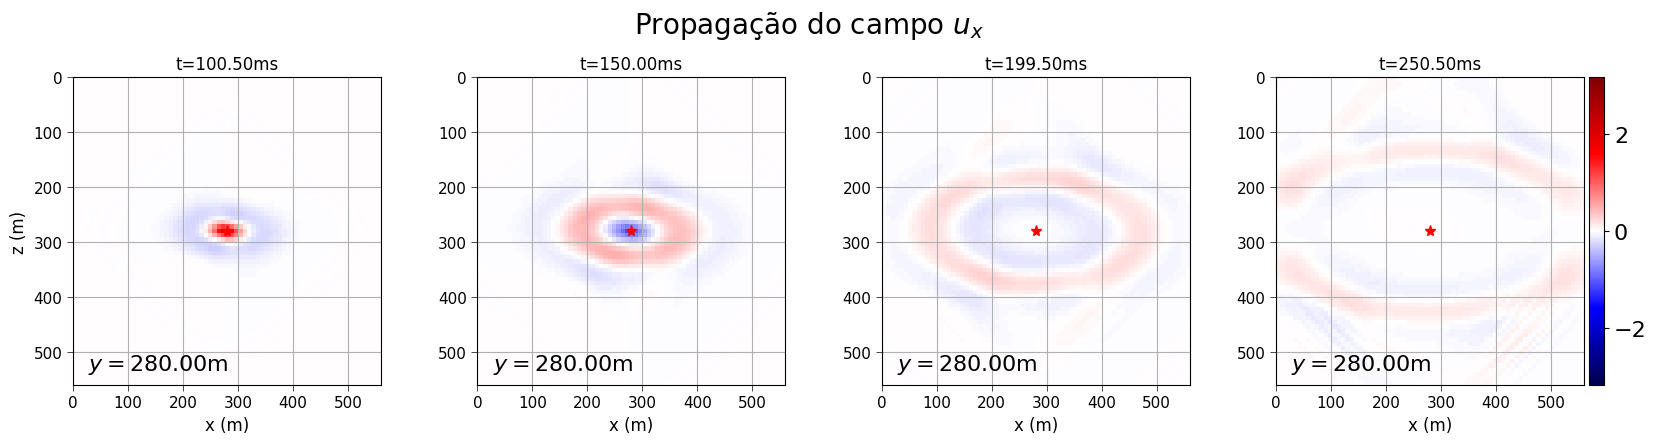

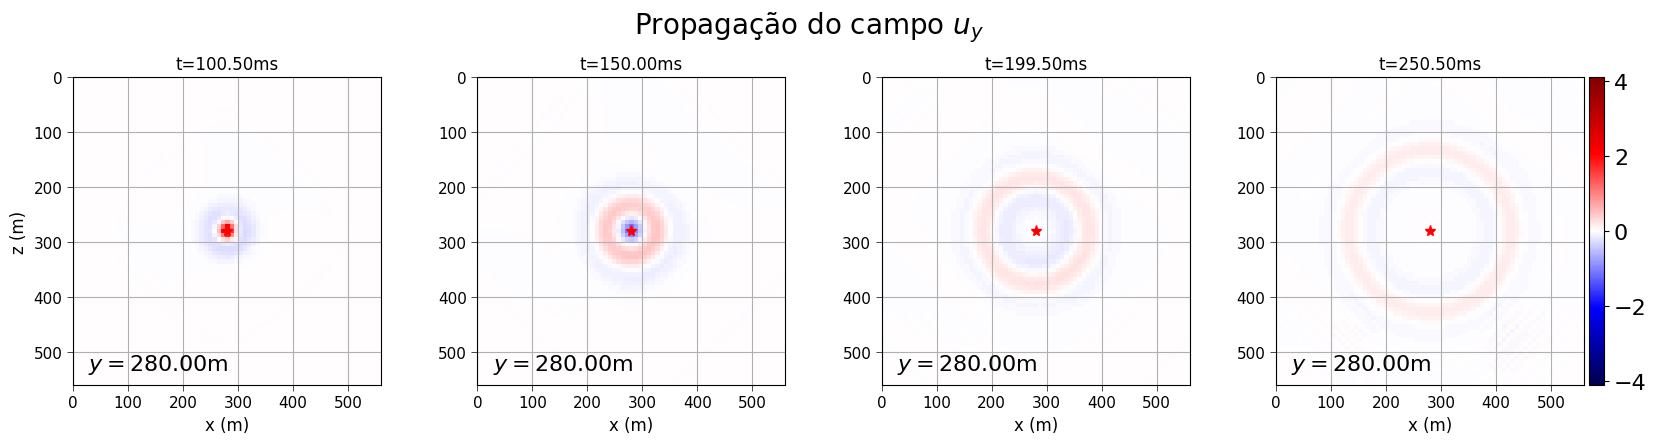

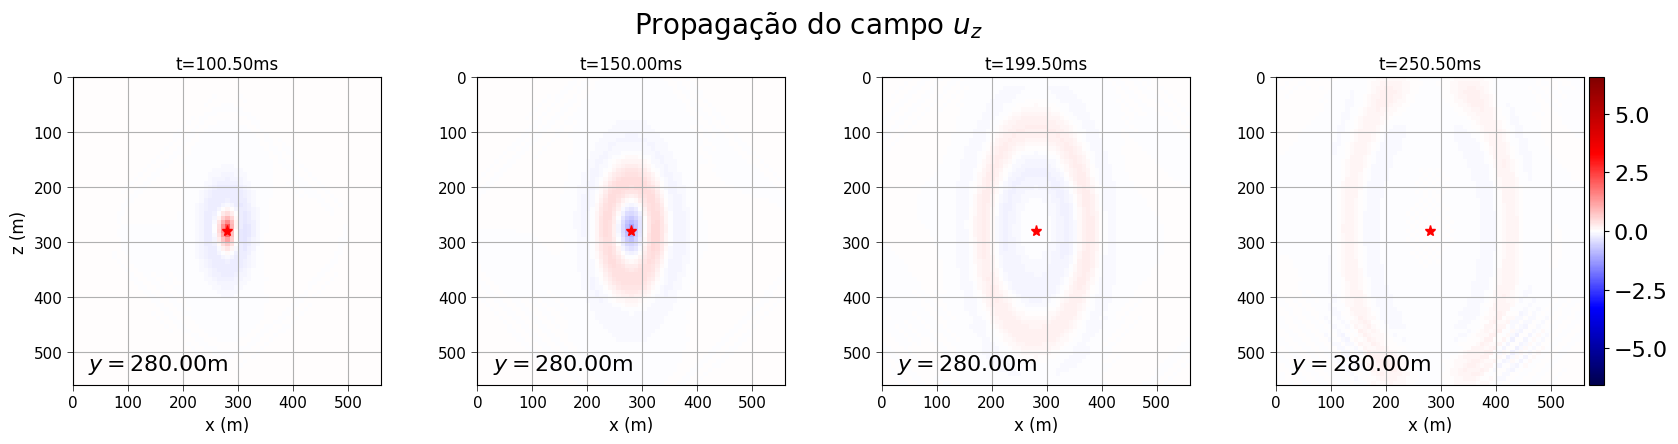

In [ ]:
plot_wavefield_slice(u[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $u_{x}$', t0=100, tn=200)
plot_wavefield_slice(u[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $u_{y}$', t0=100, tn=200)
plot_wavefield_slice(u[2], geometry, src.coordinates.data[0], model, 'Propagação do campo $u_{z}$', t0=100, tn=200)

# Resolução da alternativa b)

In [21]:
def rot(u, name):
    components=[
        u[2].dy - u[1].dz, u[0].dz - u[2].dx, u[1].dx - u[0].dy
    ]
    rotu = VectorTimeFunction(name=f'rot_{name}', grid=u.grid, space_order=u.space_order, components=components, save=u[0].save)

    return rotu

In [22]:
divu = TimeFunction(name='divu', grid=model.grid, space_order=space_order, save=geometry.nt)
rotu = VectorTimeFunction(name='rotu', grid=model.grid, space_order=space_order, save=geometry.nt)

Operator([Eq(divu, div(u))])()
Operator([Eq(rotu, rot(u, 'u'))])()

PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=0.659239, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

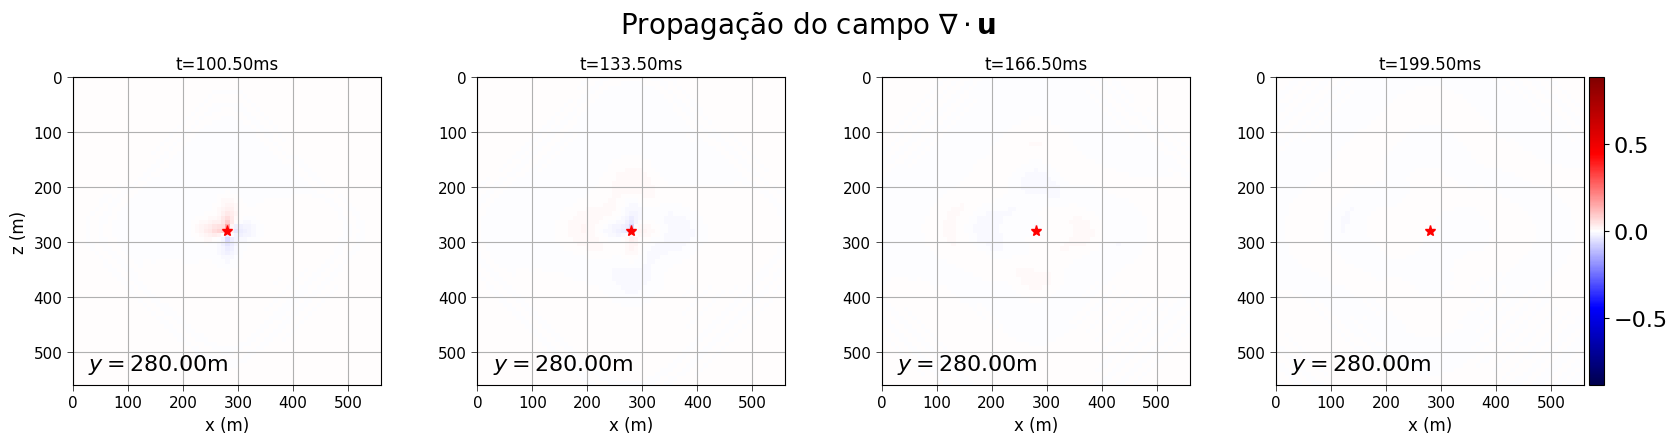

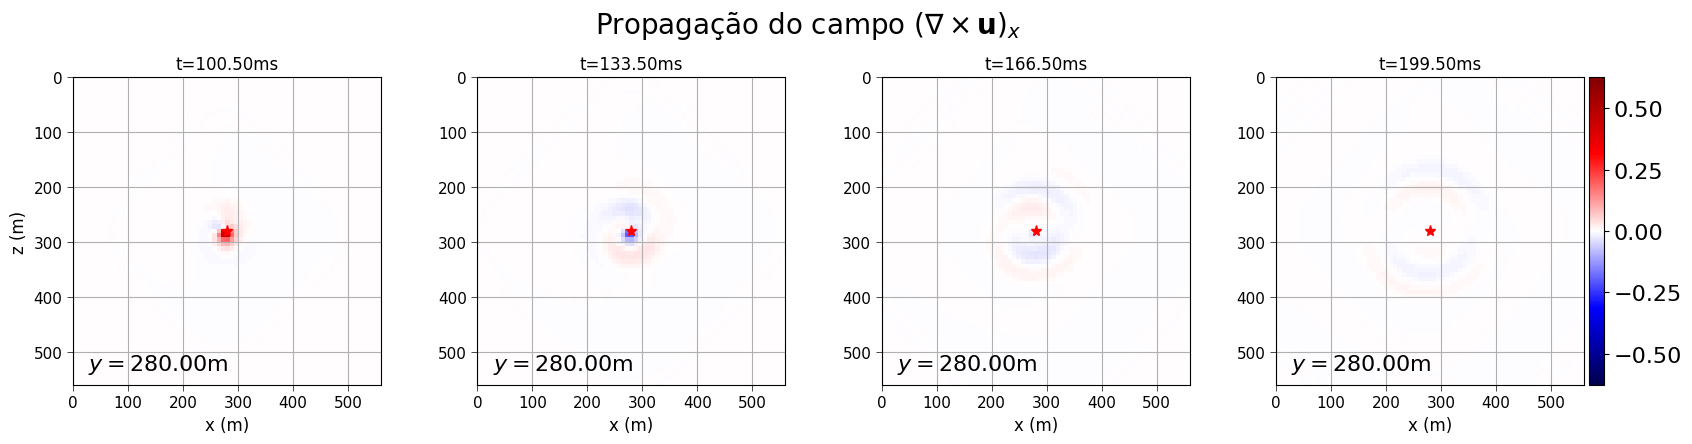

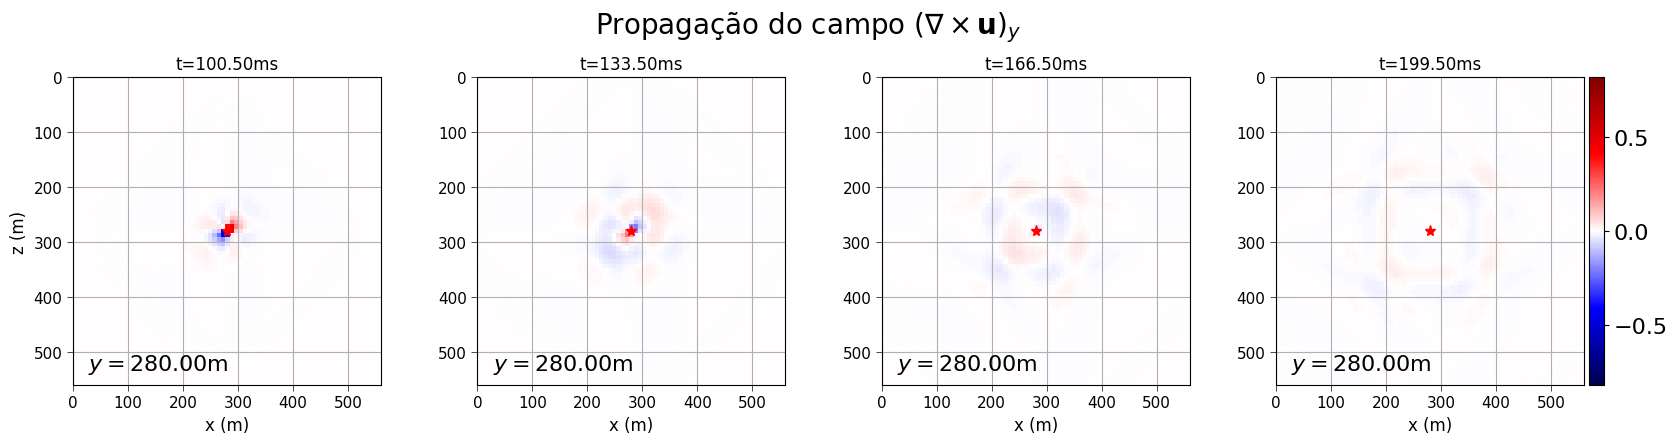

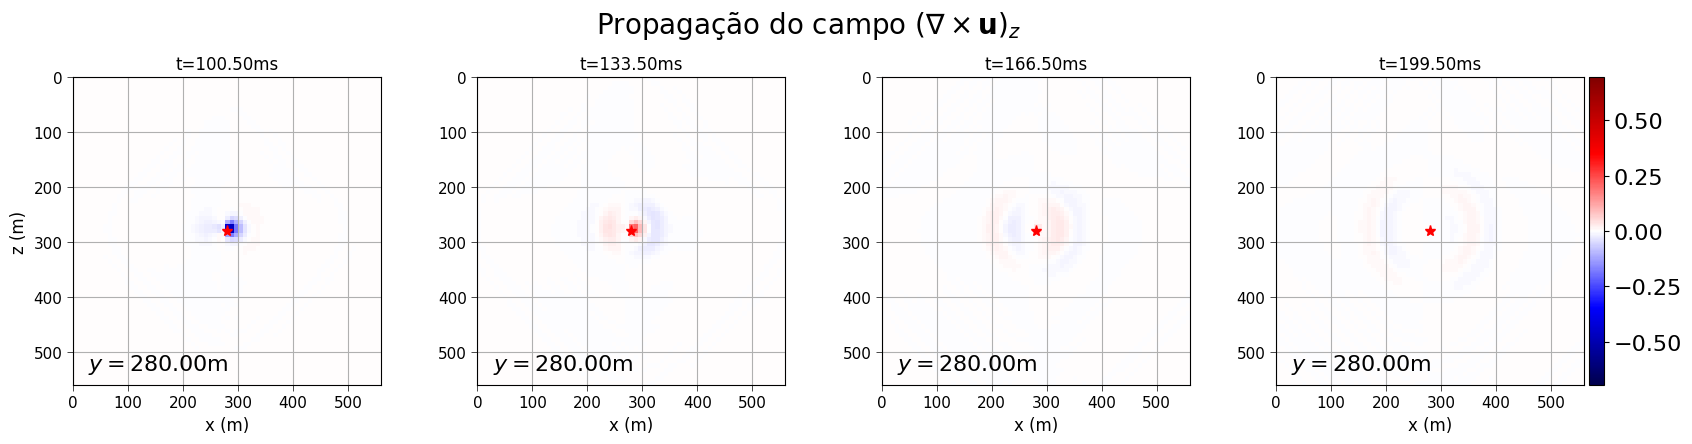

In [23]:
plot_wavefield_slice(divu, geometry, src.coordinates.data[0], model, 'Propagação do campo $\\nabla \\cdot \\mathbf{u}$', t0=100, tn=200)
plot_wavefield_slice(rotu[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $(\\nabla \\times \\mathbf{u})_x$', t0=100, tn=200)
plot_wavefield_slice(rotu[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $(\\nabla \\times \\mathbf{u})_y$', t0=100, tn=200)
plot_wavefield_slice(rotu[2], geometry, src.coordinates.data[0], model, 'Propagação do campo $(\\nabla \\times \\mathbf{u})_z$', t0=100, tn=200)

O campo $\nabla \cdot \mathbf{u}$ representa o componente compressional da onda, estando associado às ondas P, pois

$$
\begin{aligned}
    \nabla \cdot \mathbf{u} &= \frac{\partial u_x}{\partial x} + \frac{\partial u_y}{\partial y} + \frac{\partial u_z}{\partial z}\\
        &= e_{xx} + e_{yy} + e_{zz}\\
        &= \theta
\end{aligned}
$$

que é a deformação volumétrica das partículas.

O campo $\nabla \times \mathbf{u}$ representa o componente cisalhante da onda, estando associado às ondas S, pois

$$
\begin{aligned}
    \nabla \times \mathbf{u} &= \left( 
        \frac{\partial u_z}{\partial y} - \frac{\partial u_y}{\partial z},
        \frac{\partial u_x}{\partial z} - \frac{\partial u_z}{\partial x},
        \frac{\partial u_y}{\partial x} - \frac{\partial u_x}{\partial y}
    \right)\\
    &= \left( 
        e_{yz},
        e_{zx},
        e_{xy}
    \right)
\end{aligned}
$$

que são as componentes cisalhantes do tensor de deformação na forma abreviada.